**Regression Example with TensorFlow**

In [21]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [22]:
range = np.random.RandomState(42)
n = 600
X = pd.DataFrame({
    'size_sqft': np.random.normal(1200, 300, n).clip(400, 3000),
    'rooms': np.random.randint(1, 6, n),
    'age_years': np.random.randint(0, 30, n)
})
noise = range.normal(0,2000,n)
y=80*X['size_sqft']+1500*X['rooms']-1200*X['age_years']+5000+noise
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Transform using standardscaler
scaler = StandardScaler()
X_train_tr = scaler.fit_transform(X_train)
X_test_tr= scaler.transform(X_test)

In [23]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_test_tr.shape[1],)),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1,activation='relu')
])

In [24]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.mse,
              metrics=['mae'])

In [25]:
history = model.fit(X_train_tr,y_train,epochs=100,validation_data=(X_test_tr,y_test))

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 8376885248.0000 - mae: 88058.0703 - val_loss: 8673781760.0000 - val_mae: 88562.8359
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8376818688.0000 - mae: 88057.7031 - val_loss: 8673694720.0000 - val_mae: 88562.3359
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8376730624.0000 - mae: 88057.1797 - val_loss: 8673577984.0000 - val_mae: 88561.6797
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8376606208.0000 - mae: 88056.4688 - val_loss: 8673401856.0000 - val_mae: 88560.7031
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8376415232.0000 - mae: 88055.3672 - val_loss: 8673133568.0000 - val_mae: 88559.2188
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8376126464.0000 - mae: 88053.7422 - val_loss: 8672741376.0000 - val_mae: 88557.0547
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8375707648.0000 - mae: 88051.3828 - val_loss: 8672185344.0000 - val_mae: 8855

In [26]:
loss, mae = model.evaluate(X_test_tr,y_test,verbose=0)
print(f'Loss: {loss}, MAE: {mae}')

Loss: 4023639552.0, MAE: 61862.71484375


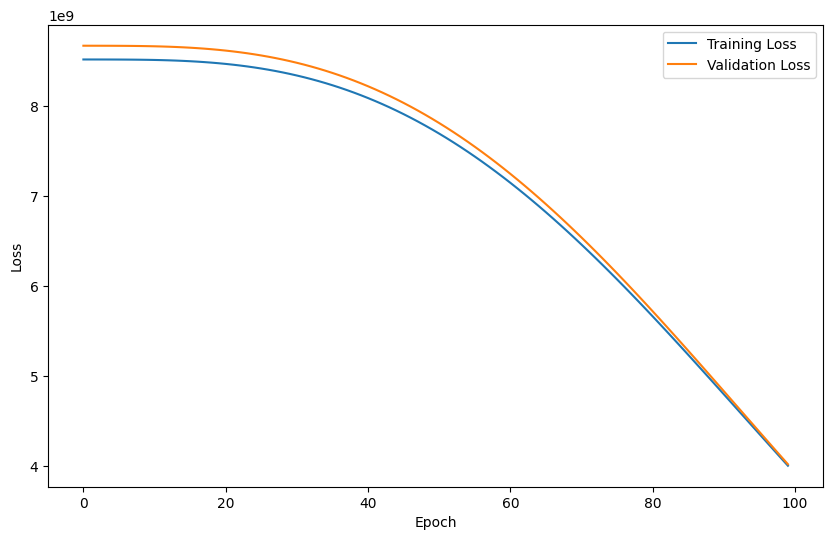

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [28]:
y_predict = model.predict(X_test_tr)
print(y_test.values)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
[ 61562.09167684 157021.36340124 109589.65563642 158774.20475003
  30584.30498796  95701.84206786 123908.45312979  37909.26600442
 129166.09275443 116642.5685558   75480.22819256  69789.20209683
 107884.19584227 108576.76743987  67803.9987993  113434.64054033
  85918.71629514 101773.62745006  86370.2163403   91909.01494019
  66807.08580584  35856.61412016  76712.22095755 116451.89260351
  69425.91182903  83110.69205429  84631.03932619 125459.51564494
 117133.68652611 105801.45312337  80849.24553267  48312.62559318
  40556.39658445 135435.58139479 114191.55992819  26930.61747322
  75632.63899848  45344.09083272 109734.22960464 125873.92454796
 112220.20635765  90982.86720697 144526.90340235  81580.98929335
  91424.35449683  82162.76204146  60437.68095041 101010.15982903
 106426.3023066   87952.43708799 125284.2610579  103335.53683646
  65690.87787624  78985.24370284  56374.70704318  75497.31119325
 129954.17842739  63103.71696521  80384.57764571  74

In [29]:
print(y_test.shape)
print(y_predict.shape)

(120,)
(120, 1)


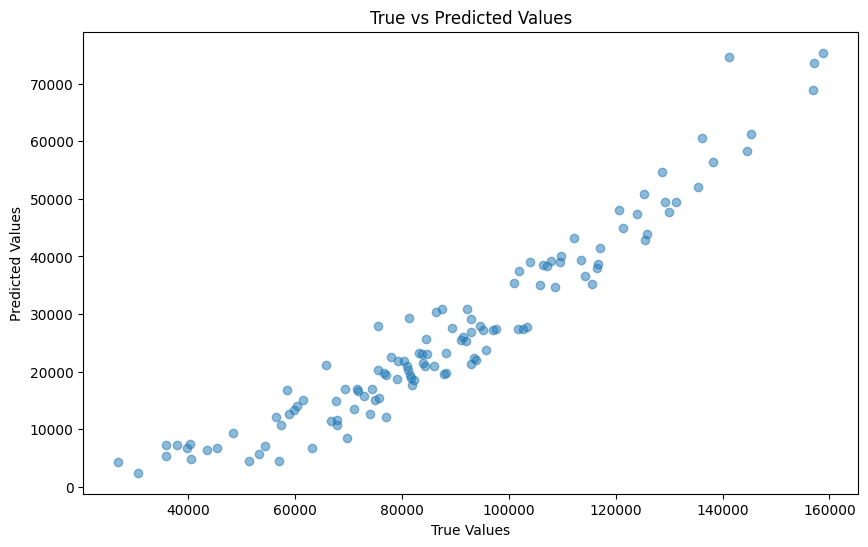

In [30]:
plt.figure(figsize=(10,6))
plt.scatter(y_test.values,y_predict.flatten(),alpha=0.5)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
plt.show()